<a href="https://colab.research.google.com/github/TetianaMar-888/Amazon_Books_project/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Аналіз вакансій

Я проаналізувала 3 вакансії
1. Middle Data Scientist
https://jobs.dou.ua/companies/ukrsibbank/vacancies/346809/?from=list_hot
2. Graduate Data Scientist
https://jobs.bendingspoons.com/positions/69d8b3196288fd924641f5df?student=true
3. Data Scientist
https://djinni.co/jobs/832382-data-scientist/

In [ ]:
from huggingface_hub import hf_hub_download
import pandas as pd
import json

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/project_data', exist_ok=True)

# 2. Завантаження відгуків (кешується автоматично huggingface_hub)
from huggingface_hub import hf_hub_download
import json
import pandas as pd

path = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename="raw/review_categories/Books.jsonl",
    repo_type="dataset"
)

records = []
with open(path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 50000:
            break
        records.append(json.loads(line))

reviews_df = pd.DataFrame(records)
print("Reviews:", reviews_df.shape)

# 3. Завантаження метаданих (фільтруємо одразу по потрібних parent_asin)
wanted_asins = set(reviews_df["parent_asin"])

meta_path = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename="raw/meta_categories/meta_Books.jsonl",
    repo_type="dataset"
)

meta_records = []
with open(meta_path, 'r', encoding='utf-8') as f:
    for line in f:
        rec = json.loads(line)
        if rec.get("parent_asin") in wanted_asins:
            meta_records.append(rec)

meta_df = pd.DataFrame(meta_records)
print("Meta:", meta_df.shape)

# 4. Приведення "проблемних" колонок до строк (щоб parquet не падав)
for col in meta_df.select_dtypes(include="object").columns:
    meta_df[col] = meta_df[col].astype(str)

for col in reviews_df.select_dtypes(include="object").columns:
    reviews_df[col] = reviews_df[col].astype(str)

# 5. Збереження на Google Drive (НЕ /content!)
reviews_df.to_parquet("/content/drive/MyDrive/project_data/reviews_books_sample.parquet")
meta_df.to_parquet("/content/drive/MyDrive/project_data/meta_books_sample.parquet")

print("Готово! Файли збережено на Drive.")

raw/review_categories/Books.jsonl:   0%|          | 0.00/20.1G [00:00<?, ?B/s]

Reviews: (50000, 10)


raw/meta_categories/meta_Books.jsonl:   0%|          | 0.00/14.7G [00:00<?, ?B/s]

Meta: (44567, 16)
Готово! Файли збережено на Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
reviews_df = pd.read_parquet("/content/drive/MyDrive/project_data/reviews_books_sample.parquet")
meta_df = pd.read_parquet("/content/drive/MyDrive/project_data/meta_books_sample.parquet")

print(reviews_df.shape, meta_df.shape)

Mounted at /content/drive
(50000, 10) (44567, 16)


In [ ]:
#мерджимо дані з двох файлів в один
df = reviews_df.merge(meta_df, on="parent_asin", how="left", suffixes=("_review", "_book"))
print(df.shape)
print(df.isnull().sum())

(50000, 25)
rating               0
title_review         0
text                 0
images_review        0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
main_category        0
title_book           0
subtitle             0
author               0
average_rating       0
rating_number        0
features             0
description          0
price                0
images_book          0
videos               0
store                0
categories           0
details              0
bought_together      0
dtype: int64


In [ ]:
df.to_parquet("/content/drive/MyDrive/project_data/merged_books.parquet")
print("Збережено!")

Збережено!


#Підготовка даних для аналізу

In [ ]:
# Типи даних
print(df.dtypes)

# Розподіл цільової змінної (rating)
print(df["rating"].value_counts().sort_index())

# Приклади текстових полів
df[["title_review", "text", "description", "price", "average_rating"]].head(10)

rating               float64
title_review          object
text                  object
images_review         object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
main_category         object
title_book            object
subtitle              object
author                object
average_rating       float64
rating_number          int64
features              object
description           object
price                 object
images_book           object
videos                object
store                 object
categories            object
details               object
bought_together       object
dtype: object
rating
1.0     1446
2.0     1774
3.0     4463
4.0    10225
5.0    32092
Name: count, dtype: int64


,title_review,text,description,price,average_rating
0,Not a watercolor book! Seems like copies imo.,It is definitely not a watercolor book. The p...,[],5.99,1.0
1,Updated: after 1st arrived damaged this one is...,Updated: after first book arrived very damaged...,"['About the Author', 'Author, activist, founde...",10.49,4.7
2,Excellent! I love it!,I bought it for the bag on the front so it pai...,"['Book Description', 'Make 35 gorgeous crochet...",21.95,4.6
3,Updated after 1st arrived damaged. Excellent,Updated: after 1st arrived damaged the replace...,"['About the Author', ""Camilla d'Errico"", 'has ...",None,4.8
4,Beautiful patterns!,I love this book! The patterns are lovely. I ...,"['About the Author', 'TANYA ALPERT is a knitwe...",19.61,4.3
5,Missing the sketch pad,Missing the sketch pad. Even worse I realized ...,"['About the Author', 'Carla Sonheim', 'is an i...",None,4.1
6,"Beautiful, but should only be printed on 1 sid...",Seriously one of only a few books they I have ...,"['About the Author', 'Jane Davenport is an art...",13.99,4.8
7,Bought for myself & I love it!,I love this book. I was not blessed with arti...,"['About the Author', ""Lorna Scobie is a London...",15.99,4.7
8,"Half the size of her other books, but same pri...",I really wanted to like this book bc I have he...,"['From the Author', '""Watercolor With Me: In T...",15.89,4.5
9,Crease down entire side of every page!!!,Every page has a crease running the entire len...,"['Review', '""...a coloring book even adults wi...",12.15,4.7


In [ ]:
import numpy as np

# Повертаємо текстові "None"/"nan"/"[]" у справжні NaN
df = df.replace(["None", "none", "nan", "NaN", "[]", ""], np.nan)

# Тепер перевір реальні пропуски
print(df.isnull().sum())
print(df.isnull().mean().sort_values(ascending=False) * 100)  # у відсотках

/tmp/ipykernel_7911/3467775301.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(["None", "none", "nan", "NaN", "[]", ""], np.nan)


rating                   0
title_review             0
text                     1
images_review        48989
asin                     0
parent_asin              0
user_id                  0
timestamp                0
helpful_vote             0
verified_purchase        0
main_category           38
title_book               0
subtitle              5002
author                8453
average_rating           0
rating_number            0
features              1820
description          13939
price                 5870
images_book           5709
videos               43634
store                  594
categories            1666
details                  0
bought_together      50000
dtype: int64
bought_together      100.000
images_review         97.978
videos                87.268
description           27.878
author                16.906
price                 11.740
images_book           11.418
subtitle              10.004
features               3.640
categories             3.332
store                 

In [ ]:
# 1. Видаляємо повністю порожню колонку
df = df.drop(columns=["bought_together"])

# 2. Бінарні індикатори замість спроби "відновити" зображення/відео
df["has_image_review"] = df["images_review"].notna().astype(int)
df["has_video"] = df["videos"].notna().astype(int)
df = df.drop(columns=["images_review", "videos", "images_book"])

# 3. Видаляємо 1 рядок без тексту відгуку (критична колонка)
df = df.dropna(subset=["text"])

# 4. Заповнення категоріальних пропусків
for col in ["author", "subtitle", "store", "main_category", "categories", "features"]:
    df[col] = df[col].fillna("Unknown")

# 5. description — окрема бінарна ознака + fallback-текст
df["has_description"] = df["description"].notna().astype(int)
df["description"] = df["description"].fillna("")

print(df.shape)
print(df.isnull().sum())  # price ще лишиться — почистимо окремо нижче

(49999, 24)
rating                  0
title_review            0
text                    0
asin                    0
parent_asin             0
user_id                 0
timestamp               0
helpful_vote            0
verified_purchase       0
main_category           0
title_book              0
subtitle                0
author                  0
average_rating          0
rating_number           0
features                0
description             0
price                5870
store                   0
categories              0
details                 0
has_image_review        0
has_video               0
has_description         0
dtype: int64


In [ ]:
import re

def clean_price(val):
    if pd.isna(val):
        return np.nan
    val = str(val)
    match = re.search(r"[\d]+\.?\d*", val)  # витягуємо перше число
    return float(match.group()) if match else np.nan

df["price_clean"] = df["price"].apply(clean_price)
print(df["price_clean"].describe())
print(df["price_clean"].isnull().sum())

count    43182.000000
mean        16.678015
std         42.063656
min          0.000000
25%          7.990000
50%         12.490000
75%         17.950000
max       4975.500000
Name: price_clean, dtype: float64
6817


In [ ]:
df["price_clean"] = df.groupby("main_category")["price_clean"].transform(
    lambda x: x.fillna(x.median())
)
df["price_clean"] = df["price_clean"].fillna(df["price_clean"].median())

print(df["price_clean"].isnull().sum())

0


In [ ]:
#Тепер розпарсимо description та features.Зараз це рядки, що виглядають як списки, бо ми раніше зробили astype(str). Перетворимо назад у справжній текст
import ast

def parse_list_str(val):
    if not val or val == "" or val == "Unknown":
        return ""
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return " ".join(str(x) for x in parsed)
        return str(parsed)
    except (ValueError, SyntaxError):
        return str(val)  # якщо не парситься - лишаємо як є

df["description_clean"] = df["description"].apply(parse_list_str)
df["features_clean"] = df["features"].apply(parse_list_str)

# Перевірка
df[["description_clean", "features_clean"]].head(3)
print(df["description_clean"].str.len().describe())

count     49999.000000
mean       3985.075702
std        8117.777899
min           0.000000
25%           0.000000
50%         976.000000
75%        3531.500000
max      159647.000000
Name: description_clean, dtype: float64


In [ ]:
df["full_text"] = (
    df["title_review"].fillna("") + ". " +
    df["text"].fillna("") + ". " +
    df["description_clean"]
)

print(df["full_text"].str.len().describe())

count     49999.000000
mean       4800.752795
std        8264.082887
min           6.000000
25%         599.000000
50%        1912.000000
75%        4754.000000
max      159946.000000
Name: full_text, dtype: float64


In [ ]:
# Враховуючи розподіл (64% — 5 зірок), робимо 3-класовий рейтинг
def to_sentiment(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(to_sentiment)
print(df["sentiment"].value_counts())
print(df["sentiment"].value_counts(normalize=True) * 100)

sentiment
positive    42316
neutral      4463
negative     3220
Name: count, dtype: int64
sentiment
positive    84.633693
neutral      8.926179
negative     6.440129
Name: proportion, dtype: float64


In [ ]:
#Зберігаємо очищений датафрейм
df.to_parquet("/content/drive/MyDrive/project_data/books_cleaned.parquet")
print("Збережено!")

Збережено!


#EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_parquet("/content/drive/MyDrive/project_data/books_cleaned.parquet")

print(df.shape)
df.head()

Mounted at /content/drive
(49999, 32)


,rating,title_review,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,main_category,...,has_video,has_description,price_clean,description_clean,features_clean,full_text,sentiment,text_length,text_clean,title_review_clean
0,1.0,Not a watercolor book! Seems like copies imo.,It is definitely not a watercolor book. The p...,B09BGPFTDB,B09BGPFTDB,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1642399598485,0,True,Books,...,0,0,5.99,,This incredible adult coloring book is the per...,Not a watercolor book! Seems like copies imo.....,negative,1414,It is definitely not a watercolor book. The pa...,Not a watercolor book! Seems like copies imo.
1,5.0,Updated: after 1st arrived damaged this one is...,Updated: after first book arrived very damaged...,0593235657,0593235657,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1640629604904,1,True,Books,...,1,1,10.49,"About the Author Author, activist, founder of ...","This stunning hardcover journal is a bold, int...",Updated: after 1st arrived damaged this one is...,positive,92,Updated: after first book arrived very damaged...,Updated: after 1st arrived damaged this one is...
2,5.0,Excellent! I love it!,I bought it for the bag on the front so it pai...,1782490671,1782490671,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1640383495102,0,True,Books,...,0,1,21.95,Book Description Make 35 gorgeous crochet proj...,Make 35 gorgeous crochet projects all incorpor...,Excellent! I love it!. I bought it for the bag...,positive,200,I bought it for the bag on the front so it pai...,Excellent! I love it!
3,5.0,Updated after 1st arrived damaged. Excellent,Updated: after 1st arrived damaged the replace...,0593138228,0593138228,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1640364906602,0,False,Books,...,0,1,13.34,About the Author Camilla d'Errico has gained w...,A stylish sketchbook from acclaimed manga arti...,Updated after 1st arrived damaged. Excellent. ...,positive,80,Updated: after 1st arrived damaged the replace...,Updated after 1st arrived damaged. Excellent
4,5.0,Beautiful patterns!,I love this book! The patterns are lovely. I ...,0823098079,0823098079,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1637312253230,0,True,Books,...,0,1,19.61,About the Author TANYA ALPERT is a knitwear de...,"Haiku, the graceful and evocative form of Japa...",Beautiful patterns!. I love this book! The pat...,positive,609,I love this book! The patterns are lovely. I a...,Beautiful patterns!


In [ ]:
df.head()

,rating,title_review,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,main_category,...,has_video,has_description,price_clean,description_clean,features_clean,full_text,sentiment,text_length,text_clean,title_review_clean
0,1.0,Not a watercolor book! Seems like copies imo.,It is definitely not a watercolor book. The p...,B09BGPFTDB,B09BGPFTDB,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1642399598485,0,True,Books,...,0,0,5.99,,This incredible adult coloring book is the per...,Not a watercolor book! Seems like copies imo.....,negative,1414,It is definitely not a watercolor book. The pa...,Not a watercolor book! Seems like copies imo.
1,5.0,Updated: after 1st arrived damaged this one is...,Updated: after first book arrived very damaged...,0593235657,0593235657,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1640629604904,1,True,Books,...,1,1,10.49,"About the Author Author, activist, founder of ...","This stunning hardcover journal is a bold, int...",Updated: after 1st arrived damaged this one is...,positive,92,Updated: after first book arrived very damaged...,Updated: after 1st arrived damaged this one is...
2,5.0,Excellent! I love it!,I bought it for the bag on the front so it pai...,1782490671,1782490671,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1640383495102,0,True,Books,...,0,1,21.95,Book Description Make 35 gorgeous crochet proj...,Make 35 gorgeous crochet projects all incorpor...,Excellent! I love it!. I bought it for the bag...,positive,200,I bought it for the bag on the front so it pai...,Excellent! I love it!
3,5.0,Updated after 1st arrived damaged. Excellent,Updated: after 1st arrived damaged the replace...,0593138228,0593138228,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1640364906602,0,False,Books,...,0,1,13.34,About the Author Camilla d'Errico has gained w...,A stylish sketchbook from acclaimed manga arti...,Updated after 1st arrived damaged. Excellent. ...,positive,80,Updated: after 1st arrived damaged the replace...,Updated after 1st arrived damaged. Excellent
4,5.0,Beautiful patterns!,I love this book! The patterns are lovely. I ...,0823098079,0823098079,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1637312253230,0,True,Books,...,0,1,19.61,About the Author TANYA ALPERT is a knitwear de...,"Haiku, the graceful and evocative form of Japa...",Beautiful patterns!. I love this book! The pat...,positive,609,I love this book! The patterns are lovely. I a...,Beautiful patterns!


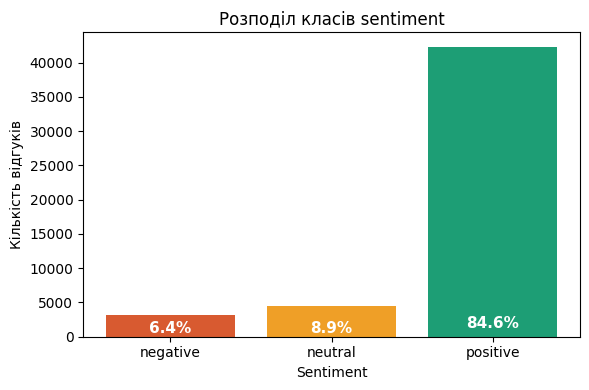

In [ ]:
#Графік 1 — Розподіл sentiment (баланс класів)
import matplotlib.pyplot as plt

order = ["negative", "neutral", "positive"]
counts = df["sentiment"].value_counts().reindex(order)
percentages = df["sentiment"].value_counts(normalize=True).reindex(order) * 100

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(order, counts.values, color=["#D85A30", "#EF9F27", "#1D9E75"])

# Підпис з відсотком під кожним баром (трохи вище осі X, всередині стовпця)
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 0.02,  # трохи вище нуля, всередині стовпця, ближче до низу
        f"{pct:.1f}%",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold", color="white"
    )

ax.set_title("Розподіл класів sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Кількість відгуків")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/sentiment_distribution.png", dpi=150)
plt.show()

Висновки: чітко бачимо дисбаланс класів. Потрібно буде збалансовувати і встановлювати статіфайд, перевіряти де модель найчастіше помилятиметься. На мою думку, це буде в негативному та нейтральному класах через брак даних.

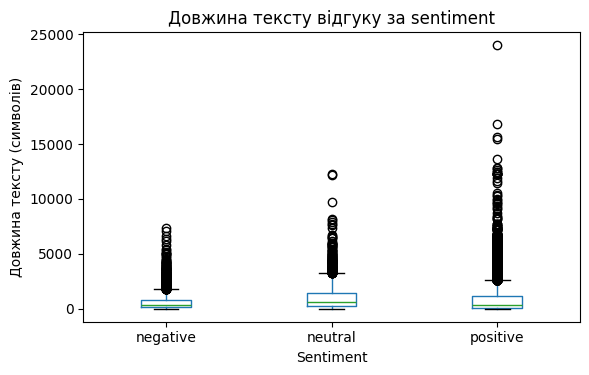

In [ ]:
#Графік 2 — Довжина тексту відгуку по класах (boxplot)

df["text_length"] = df["text"].str.len()

fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column="text_length", by="sentiment", ax=ax,
           positions=[0,1,2], grid=False)
ax.set_title("Довжина тексту відгуку за sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Довжина тексту (символів)")
plt.suptitle("")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/text_length_by_sentiment.png", dpi=150)
plt.show()

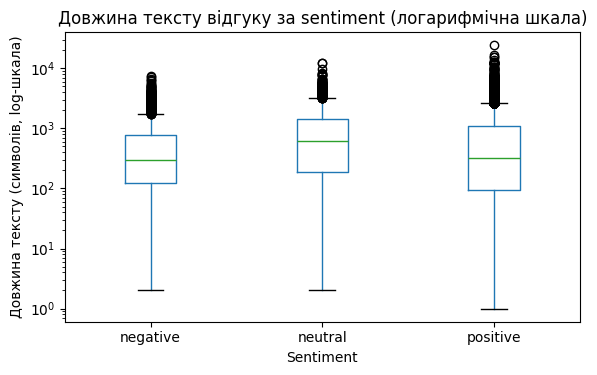

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column="text_length", by="sentiment", ax=ax,
           positions=[0,1,2], grid=False)
ax.set_yscale("log")
ax.set_title("Довжина тексту відгуку за sentiment (логарифмічна шкала)")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Довжина тексту (символів, log-шкала)")
plt.suptitle("")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/text_length_by_sentiment.png", dpi=150)
plt.show()

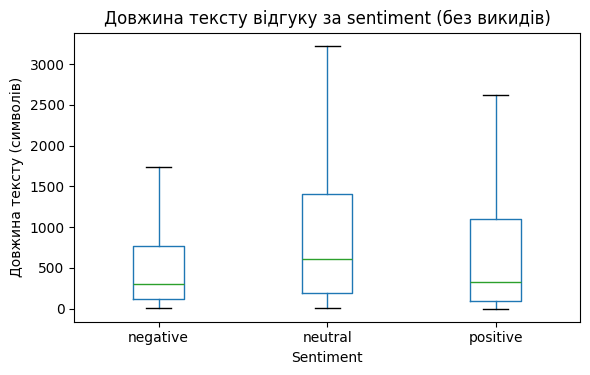

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column="text_length", by="sentiment", ax=ax,
           positions=[0,1,2], grid=False, showfliers=False)
ax.set_title("Довжина тексту відгуку за sentiment (без викидів)")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Довжина тексту (символів)")
plt.suptitle("")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/text_length_by_sentiment_no_outliers.png", dpi=150)
plt.show()

Висновки: Медіана довжини тексту neutral (~ 600 символів) вища за negative (~ 290) і positive (~ 310). Це контрінтуїтивно на перший погляд — можна було б очікувати, що негативні відгуки найдовші (люди детально скаржаться), але тут neutral виявився найбагатшим на текст. Можна припустити що люди, які ставлять "середню" оцінку (3 зірки), частіше детально пояснюють чому — і плюси, і мінуси, тоді як при явно позитивному чи негативному досвіді відгук частіше короткий і емоційний.

        price_clean  helpful_vote  average_rating  rating_number  text_length
count  49999.000000  49999.000000    49999.000000   49999.000000  49999.00000
mean      16.122159      3.076062        4.437297    4775.581752    782.50819
std       39.148712     23.041188        0.378823   24342.988849   1043.09131
min        0.000000      0.000000        1.000000       1.000000      1.00000
25%        8.250000      0.000000        4.300000      45.000000    102.00000
50%       13.340000      0.000000        4.500000     261.000000    344.00000
75%       16.880000      2.000000        4.700000    1688.000000   1114.50000
max     4975.500000   3580.000000        5.000000  616040.000000  23991.00000


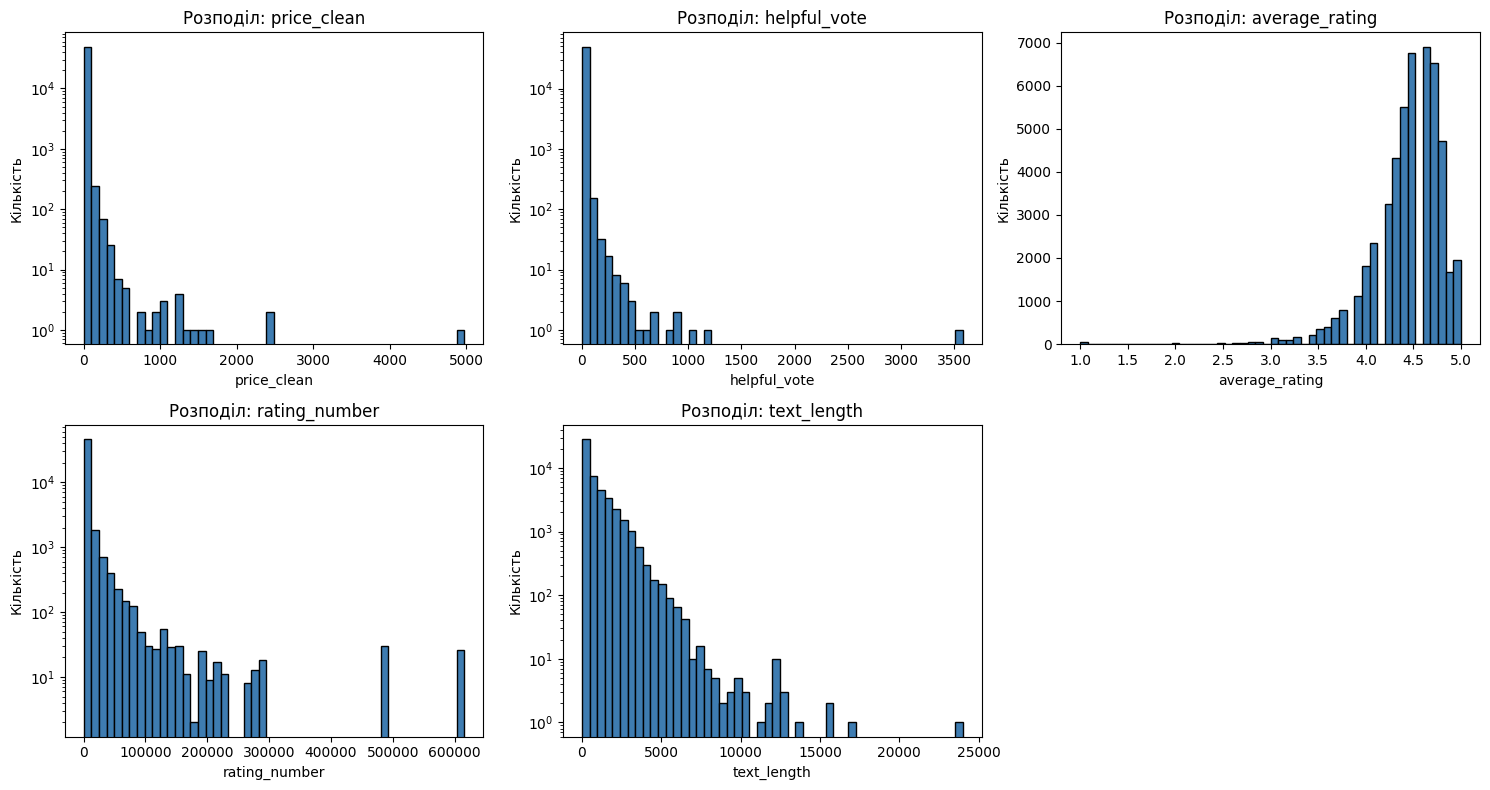

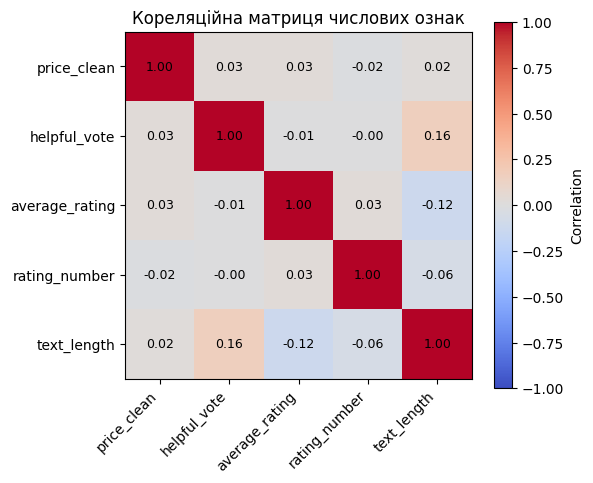

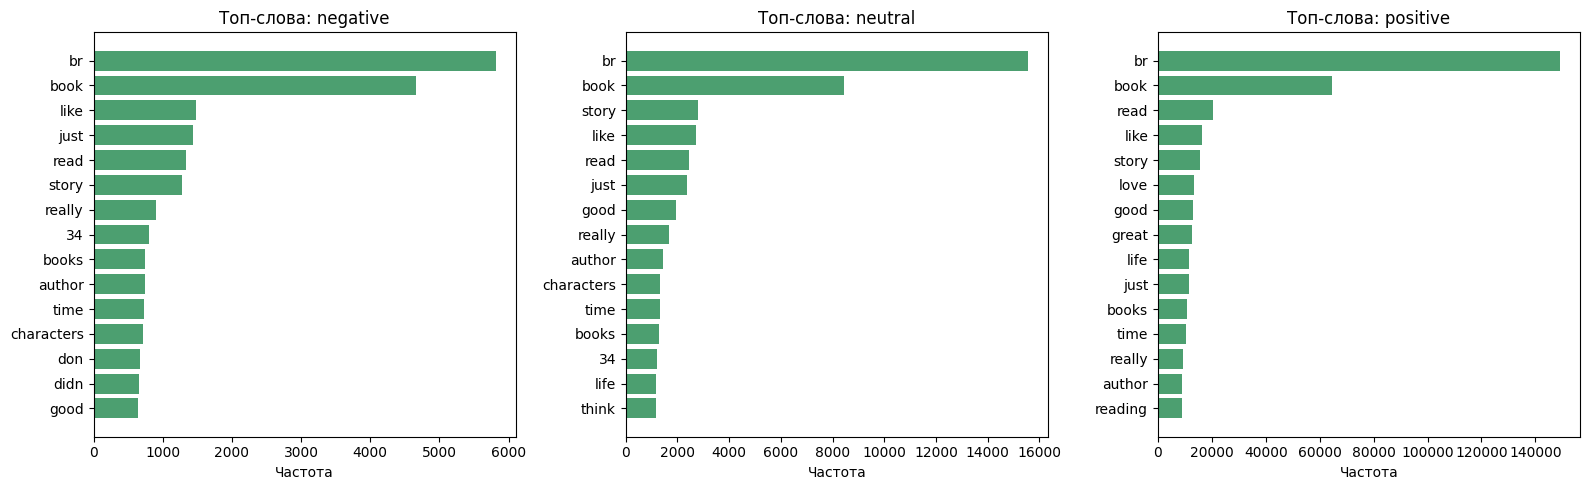

sentiment          negative    neutral   positive
verified_purchase                                
False              5.891734  10.616969  83.491297
True               6.869141   7.603465  85.527395


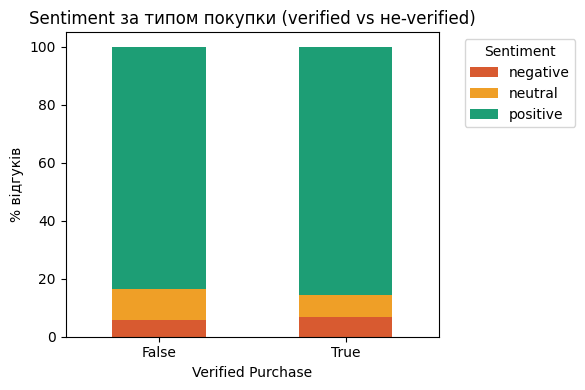

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# ============================================================
# 1. Описова статистика + гістограми числових змінних
# ============================================================
numeric_cols = ["price_clean", "helpful_vote", "average_rating", "rating_number", "text_length"]
print(df[numeric_cols].describe())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, color="#3E7CB1", edgecolor="black")
    axes[i].set_title(f"Розподіл: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Кількість")
    # Для сильно skewed змінних - log-шкала по Y для кращої читабельності
    if col in ["price_clean", "helpful_vote", "rating_number", "text_length"]:
        axes[i].set_yscale("log")

axes[-1].axis("off")  # прибираємо зайву порожню комірку (6 підграфіків - 5 змінних)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/numeric_distributions.png", dpi=150)
plt.show()


# ============================================================
# 2. Кореляційна матриця числових ознак
# ============================================================
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)

# Підписи значень кореляції на кожній клітинці
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                 color="black", fontsize=9)

ax.set_title("Кореляційна матриця числових ознак")
fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/correlation_matrix.png", dpi=150)
plt.show()


# ============================================================
# 3. Топ-слова по класах sentiment
# ============================================================
def top_words_by_class(texts, top_n=15):
    vectorizer = CountVectorizer(stop_words="english", max_features=5000, min_df=5)
    X = vectorizer.fit_transform(texts)
    word_counts = np.asarray(X.sum(axis=0)).flatten()
    vocab = vectorizer.get_feature_names_out()
    top_idx = word_counts.argsort()[::-1][:top_n]
    return [(vocab[i], word_counts[i]) for i in top_idx]

sentiments = ["negative", "neutral", "positive"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, sent in zip(axes, sentiments):
    subset_texts = df.loc[df["sentiment"] == sent, "text"].fillna("")
    top_words = top_words_by_class(subset_texts, top_n=15)
    words, counts = zip(*top_words)
    ax.barh(words[::-1], counts[::-1], color="#4C9F70")
    ax.set_title(f"Топ-слова: {sent}")
    ax.set_xlabel("Частота")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/top_words_by_sentiment.png", dpi=150)
plt.show()


# ============================================================
# 4. Verified purchase vs sentiment
# ============================================================
cross_tab = pd.crosstab(df["verified_purchase"], df["sentiment"], normalize="index") * 100
print(cross_tab)

fig, ax = plt.subplots(figsize=(6, 4))
cross_tab[sentiments].plot(kind="bar", stacked=True, ax=ax,
                             color=["#D85A30", "#EF9F27", "#1D9E75"])
ax.set_title("Sentiment за типом покупки (verified vs не-verified)")
ax.set_xlabel("Verified Purchase")
ax.set_ylabel("% відгуків")
ax.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/verified_purchase_sentiment.png", dpi=150)
plt.show()

Одна важлива проблема, яку обов'язково треба виправити, це "br" і "34" в топ-словах.
На графіку 3 — br це найчастіше слово в усіх трьох класах і 34 теж повторюється. Це схоже на залишки нерозкодованого HTML.
Тобто наш text/full_text містить необроблену HTML-розмітку, яка засмічує весь текстовий аналіз. Це треба почистити зараз, до векторизації тексту.

In [ ]:
import re
import html

def clean_text(text):
    if pd.isna(text):
        return ""
    text = html.unescape(text)              # &#34; -> ", &amp; -> & тощо
    text = re.sub(r"<br\s*/?>", " ", text)   # прибрати <br> теги
    text = re.sub(r"<[^>]+>", " ", text)     # прибрати будь-які інші HTML-теги
    text = re.sub(r"\s+", " ", text).strip() # прибрати зайві пробіли
    return text

df["text_clean"] = df["text"].apply(clean_text)
df["title_review_clean"] = df["title_review"].apply(clean_text)
df["description_clean"] = df["description_clean"].apply(clean_text)

# Перебудуй full_text і text_length на чистому тексті
df["full_text"] = df["title_review_clean"] + ". " + df["text_clean"] + ". " + df["description_clean"]
df["text_length"] = df["text_clean"].str.len()

df.to_parquet("/content/drive/MyDrive/project_data/books_cleaned.parquet")

In [ ]:
df[df["price_clean"] > 500][["title_book", "price", "price_clean"]].head(10)

,title_book,price,price_clean
906,Delights from the Garden of Eden: A Cookbook a...,977.87,977.87
8636,Gift of Time,893.44,893.44
11083,Gay Christian 101: Spiritual Self-Defense for ...,1500.0,1500.00
13624,Shelby Cobra: The Snake that Conquered the World,559.43,559.43
15843,Margin of Safety: Risk-Averse Value Investing ...,from 4975.50,4975.50
17712,PDCA/Test: A Quality Framework for Software Te...,700.0,700.00
18645,"Ariel's Journey (The Ice Horse Adventures, Boo...",1445.0,1445.00
20076,Color Your Own Stickers Inspirations: Just Col...,1292.93,1292.93
25896,Lotus The Marque: The complete history of Lotu...,998.77,998.77
25951,Vincent Desiderio: Recent Paintings,1599.97,1599.97


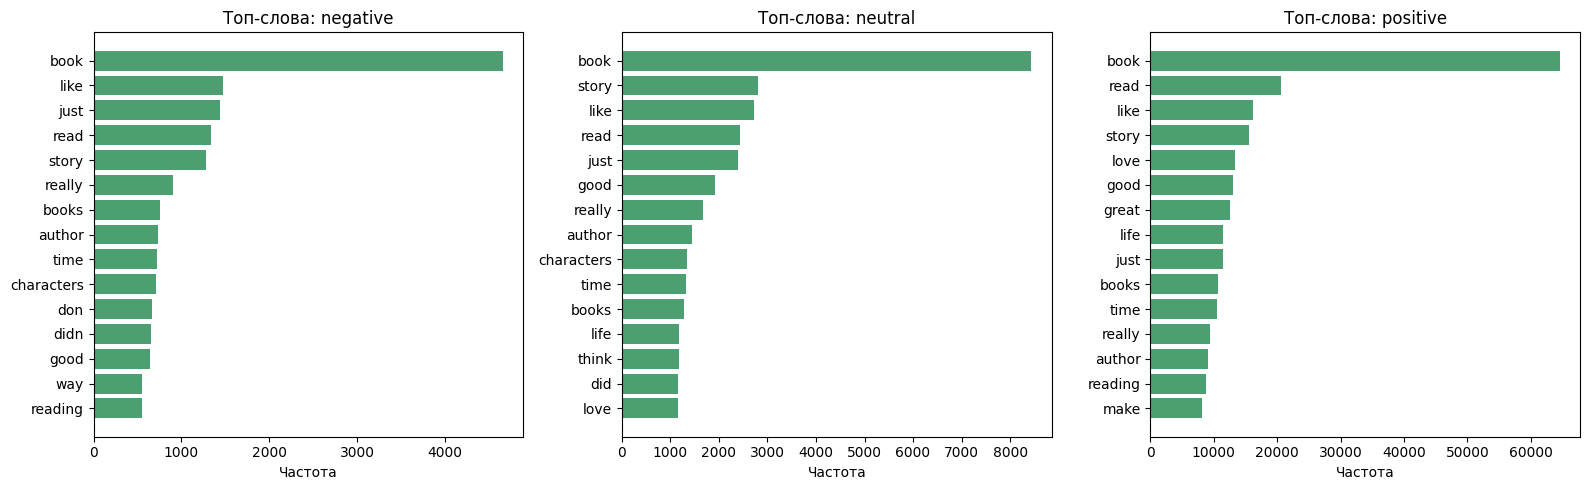

In [ ]:
# Після очищення br та 34
#  Топ-слова по класах sentiment
# ============================================================
def top_words_by_class(texts, top_n=15):
    vectorizer = CountVectorizer(stop_words="english", max_features=5000, min_df=5)
    X = vectorizer.fit_transform(texts)
    word_counts = np.asarray(X.sum(axis=0)).flatten()
    vocab = vectorizer.get_feature_names_out()
    top_idx = word_counts.argsort()[::-1][:top_n]
    return [(vocab[i], word_counts[i]) for i in top_idx]

sentiments = ["negative", "neutral", "positive"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, sent in zip(axes, sentiments):
    subset_texts = df.loc[df["sentiment"] == sent, "text_clean"].fillna("")
    top_words = top_words_by_class(subset_texts, top_n=15)
    words, counts = zip(*top_words)
    ax.barh(words[::-1], counts[::-1], color="#4C9F70")
    ax.set_title(f"Топ-слова: {sent}")
    ax.set_xlabel("Частота")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/top_words_by_sentiment.png", dpi=150)
plt.show()


In [ ]:
df.to_parquet("/content/drive/MyDrive/project_data/books_cleaned.parquet")
print("Збережено!")

Збережено!
